# Impact of Dried Blood Spot Diameter and Transit Time on Analyte Concentrations and Cut-Off Classification in Routine Newborn Screening

## Effect of DBS diameter on results in paired DBS

This Jupyter notebook describes the analysis of duplicate measurements of IRT and TSH in the same analytical batch, part of the following manuscript (submitted for publication in Clinical Chemistry):

{Citation placeholder - Once accepted for publication, a citation will appear here}

Please cite this paper if you re-use any of the code in this analysis.

### Library imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import statsmodels as sm

In [2]:
sns.set_style("whitegrid")

## Load plate and well information on repeats from Panthera

We have extracted plate and and well information from the Panthera using the piexif library. This is saved in the file blood_spot_pseudonymisation.csv. Load this data:

In [3]:
df = pd.read_csv('data/blood_spot_pseudonymisation.csv')
df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")

In [4]:
df.head()

,repeats_pseudonym,Episode_pseudo,plate,well,date_time
0,REPEATS201504_00001,EPI1504705,EXMSMSp1,B7,2015-04-01 12:56:42
1,REPEATS201504_00002,EPI1504705,063315440456,C7,2015-04-01 12:56:48
2,REPEATS201504_00003,EPI1504705,063315440538,H8,2015-04-02 14:11:23
3,REPEATS201504_00004,EPI1504705,063315440538,H9,2015-04-02 14:11:28
4,REPEATS201504_00005,EPI1504729,EXMSMSp1,D7,2015-04-01 13:03:35


## Load DBS metrics

Load DBS metrics, obtained using methods described in the following paper.

    Flynn N, Moat SJ, Hogg SL. A computer vision approach to the assessment of dried blood spot size and quality in newborn screening. Clin Chim Acta. 2023;547:117418.

Data is stored by Panthera instrument and month, so we load each each month separately before combining into a single dataframe. 

Note this is for all images obtained from the Panthera. We will merge with just the samples we need later.

In [5]:
year = (2015,2016,2017,2018,2019,2020,2021,2022,2023)
month = (1,2,3,4,5,6,7,8,9,10,11,12)
dataframes = []

for y in year:
    for m in month:
        try:
            filepath = 'data/dbs_metrics/' + str(y) + '-' + str(m) + '.csv'
            df_month = pd.read_csv(filepath,parse_dates=['month','date_time'])
            dataframes.append(df_month)
        except:
            print('No data for year ' + str(y) + ' and month ' + str(m))

No data for year 2015 and month 1
No data for year 2023 and month 11
No data for year 2023 and month 12


In [6]:
year = (2023,2024,2025)
month = (1,2,3,4,5,6,7,8,9,10,11,12)

for y in year:
    for m in month:
        try:
            filepath = 'data/dbs_metrics/' + str(y) + '-' + str(m) + '_new.csv'
            df_month = pd.read_csv(filepath,parse_dates=['month','date_time'])
            dataframes.append(df_month)
        except:
            print('No data for year ' + str(y) + ' and month ' + str(m))

No data for year 2023 and month 1
No data for year 2023 and month 2
No data for year 2023 and month 3
No data for year 2023 and month 4
No data for year 2023 and month 5
No data for year 2023 and month 6
No data for year 2023 and month 7
No data for year 2023 and month 8
No data for year 2023 and month 9
No data for year 2025 and month 11
No data for year 2025 and month 12


In [7]:
dbs_metrics = pd.concat(dataframes,ignore_index=True)

In [8]:
len(dbs_metrics)

423390

Now we merge with Panthera plate and well information, keeping only episodes that were punched and analysed on the same day.

In [9]:
#Make sure both dates are stored as date_time
df['date_time'] = pd.to_datetime(df['date_time'])
dbs_metrics['date_time'] = pd.to_datetime(dbs_metrics['date_time'])

In [10]:
df = pd.merge(
    df,
    dbs_metrics,
    on=["Episode_pseudo", "date_time"],
    how="inner"  # only keep matching rows
)

In [11]:
len(df)

19298

## Load GSP data

Load data including plate information from GSP

In [12]:
def report_counts(tsh, irt):
    print("TSH: " + str(len(tsh)))
    print("IRT: " + str(len(irt)))    

In [13]:
GSP_TSH = pd.read_csv('data/gspcht_0621-1125.csv',parse_dates=['RunDate'])
GSP_IRT = pd.read_csv('data/gspcf_0621-1125.csv',parse_dates=['RunDate'])

report_counts(tsh=GSP_TSH, irt=GSP_IRT)

TSH: 111498
IRT: 109278


In [14]:
GSP_TSH.head()

,RunID,Kitlot,RunDate,Plate,Well_Numeric,Well,Calibration,Analyte,Sampleix,Role,SubRole,Status,UsedForAnswer,Counts,Conc,insname,insExtCode,PlateCode,Episode_pseudo
0,1,685181,2021-06-23 16:10:13,1,3,B03,1,NTSH,15,3,0,20.0,1,940,1.120021,GSP-20210543,20210543,1016848880030377,EPI2111699
1,1,685181,2021-06-23 16:10:13,1,4,B04,1,NTSH,16,3,0,NaN,1,1587,2.407612,GSP-20210543,20210543,1016848880030377,EPI2111701
2,1,685181,2021-06-23 16:10:13,1,5,B05,1,NTSH,17,3,0,NaN,1,1235,1.707089,GSP-20210543,20210543,1016848880030377,EPI2111702
3,1,685181,2021-06-23 16:10:13,1,6,B06,1,NTSH,18,3,0,NaN,1,1120,1.478231,GSP-20210543,20210543,1016848880030377,EPI2111703
4,1,685181,2021-06-23 16:10:13,1,7,B07,1,NTSH,19,3,0,NaN,1,1144,1.525993,GSP-20210543,20210543,1016848880030377,EPI2111704


In [15]:
GSP_TSH.tail()

,RunID,Kitlot,RunDate,Plate,Well_Numeric,Well,Calibration,Analyte,Sampleix,Role,SubRole,Status,UsedForAnswer,Counts,Conc,insname,insExtCode,PlateCode,Episode_pseudo
111493,5661,759621,2025-11-03 15:19:39,2,7,B07,6628,NTSH,115,3,0,NaN,0,3416,5.897783,GSP-20210543,20210543,1017585940003810,EPI2520097
111494,5655,759621,2025-10-31 14:11:29,1,9,G09,6626,NTSH,81,3,0,20.0,1,735,0.927704,GSP-20210543,20210543,1017585940003917,EPI2519907
111495,5655,759621,2025-10-31 14:11:29,1,10,G10,6626,NTSH,82,3,0,NaN,1,1208,1.816523,GSP-20210543,20210543,1017585940003917,EPI2520091
111496,5655,759621,2025-10-31 14:11:29,1,11,G11,6626,NTSH,83,3,0,20.0,1,846,1.136283,GSP-20210543,20210543,1017585940003917,EPI2520090
111497,5655,759621,2025-10-31 14:11:29,1,12,G12,6626,NTSH,84,3,0,NaN,1,1199,1.799610,GSP-20210543,20210543,1017585940003917,EPI2520098


Drop any non-numeric concentrations

In [16]:
GSP_TSH = GSP_TSH[~GSP_TSH['Conc'].isna()]
GSP_IRT = GSP_IRT[~GSP_IRT['Conc'].isna()]

report_counts(tsh=GSP_TSH, irt=GSP_IRT)

TSH: 111418
IRT: 108779


GSP IRT has lost leading zeros on plate code due to earlier file manipulation. Fix this by adding in the leading zero if the plate code is only 11 characters (expect this to be 12)

In [17]:
GSP_IRT['PlateCode'] = GSP_IRT['PlateCode'].astype(str)
GSP_IRT.loc[GSP_IRT['PlateCode'].str.len() == 11, 'PlateCode'] = \
    '0' + GSP_IRT.loc[GSP_IRT['PlateCode'].str.len() == 11, 'PlateCode']

In [18]:
GSP_IRT['PlateCode']

0         068252740739
1         068252740739
2         068252740739
3         068252740739
4         068252740739
              ...     
109273    075402240209
109274    075402240209
109275    075402240209
109276    075402240209
109277    075402240209
Name: PlateCode, Length: 108779, dtype: object

Current GSP was in routine use from 1st July 2021. Drop results before July 2021 (these are method verification results rather than routine use)

In [19]:
GSP_TSH = GSP_TSH[GSP_TSH['RunDate'] >= "2021-07-01"]
GSP_IRT = GSP_IRT[GSP_IRT['RunDate'] >= "2021-07-01"]

report_counts(tsh=GSP_TSH, irt=GSP_IRT)

TSH: 111106
IRT: 108541


## Load Omnilab results (pre latest GSP)

Results were obtained via SQL query from the Omnilab LIMS system. Note this does not include plate information.

In [20]:
Omni_results = pd.read_csv('data/repeat_in_duplicate_0415-0925.csv',parse_dates=["Date Rec'd"])

In [21]:
len(Omni_results)

11952

Drop results after July 2021 - we can use GSP data for these and pair with plate information

In [22]:
Omni_results = Omni_results[Omni_results["Date Rec'd"]<"2021-07-01"]

In [23]:
len(Omni_results)

7394

In [24]:
Omni_results.head()

,Date Rec'd,Test Set,Test Code,Result,Episode_pseudo
0,2015-01-04,N025A,IRT Repeat 1,49.0,EPI1504705
1,2015-01-04,N025A,IRT Repeat 2,49.0,EPI1504705
2,2015-01-04,N010A,TSH Repeat 1,16.0,EPI1504729
3,2015-01-04,N010A,TSH Repeat 2,17.0,EPI1504729
4,2015-02-04,N025A,IRT Repeat 1,82.0,EPI1504780


Create a new column to identify which test the result is for (identified via Test code name)

In [25]:
Omni_results = Omni_results.copy()
Omni_results['Test'] = Omni_results['Test Code'].str.extract(r'(^[A-Za-z]+)')

Count the number of tests for each analyte

In [26]:
Omni_results['Test'].value_counts()

IRT                    4692
TSH                    2216
Methionine              198
Tyrosine                 76
Phenylalanine            76
Octanoylcarnitine        42
Decanoylcarnitine        42
Glutarylcarnitine        24
Leucine                  22
Isovalerylcarnitine       6
Name: Test, dtype: int64

There is not enough data to assess relationship for amino acids or acylcarnitines (we also have a problem for IMDs where plates are not named uniquely), so create separate dataframes for IRT and TSH only.

In [27]:
OMNI_IRT = Omni_results[Omni_results['Test'] == 'IRT'].copy()
OMNI_TSH = Omni_results[Omni_results['Test'] == 'TSH'].copy()


report_counts(tsh=OMNI_TSH, irt=OMNI_IRT)

TSH: 2216
IRT: 4692


Create placeholder values for results outside measurable range

In [28]:
# Convert values that start with '>' to 251
OMNI_TSH.loc[OMNI_TSH['Result'].astype(str).str.startswith('>'), 'Result'] = 251

# Convert values that start with '<' to 1.2
OMNI_TSH.loc[OMNI_TSH['Result'].astype(str).str.startswith('<'), 'Result'] = 1.2

report_counts(tsh=OMNI_TSH, irt=OMNI_IRT)

TSH: 2216
IRT: 4692


Check for non-numeric results

In [29]:
OMNI_TSH[pd.to_numeric(OMNI_TSH['Result'], errors='coerce').isna()]

,Date Rec'd,Test Set,Test Code,Result,Episode_pseudo,Test
1073,2016-01-25,N010A,TSH Repeat 2,:INS,EPI1601862,TSH
4818,2019-02-19,N010A,TSH Repeat 1,:NT,EPI1903467,TSH
4819,2019-02-19,N010A,TSH Repeat 2,:NT,EPI1903467,TSH
4820,2019-02-19,N010A,TSH Repeat 1,:NT,EPI1903542,TSH
4821,2019-02-19,N010A,TSH Repeat 2,:NT,EPI1903542,TSH
6371,2020-07-13,N010A,TSH Repeat 2,:NT,EPI2013339,TSH


Note :INS and :NT are codes to indicate that the sample was not tested, so we can safely exclude these.

In [30]:
OMNI_IRT[pd.to_numeric(OMNI_IRT['Result'], errors='coerce').isna()]

,Date Rec'd,Test Set,Test Code,Result,Episode_pseudo,Test


Coerce Result to float - we'll lose the non-numeric results above. 

In [31]:
OMNI_TSH['Result'] = pd.to_numeric(OMNI_TSH['Result'], errors='coerce')
OMNI_IRT['Result'] = pd.to_numeric(OMNI_IRT['Result'], errors='coerce')

report_counts(tsh=OMNI_TSH, irt=OMNI_IRT)

TSH: 2216
IRT: 4692


Now we drop rows in Omni_results where the sample already appears in the GSP dataframes (this should have already been done via the date check above, but this is a second check).

In [32]:
OMNI_TSH = OMNI_TSH[~OMNI_TSH['Episode_pseudo'].isin(GSP_TSH['Episode_pseudo'])]
OMNI_IRT = OMNI_IRT[~OMNI_IRT['Episode_pseudo'].isin(GSP_IRT['Episode_pseudo'])]

report_counts(tsh=OMNI_TSH, irt=OMNI_IRT)

TSH: 2174
IRT: 4598


## Pre-processing

After we have merged the spot metrics with plate information, the main dataframe contains many columns. We will only include a subset that we are interested in.

In [33]:
cols_to_include = ['Episode_pseudo','plate','well','date_time','number_punches','equiv_diam_mm','pred_multi','prob_multi']
df = df[cols_to_include]

Exclude any repeats that at least 7 days after the first appearance of the lab no. Routine NBS would be expected to be completed by the then, and any additional analyses are likely for quality assurance (e.g. reagent acceptance testing, method verifications)

In [34]:
# find first date for each lab_no
first_dates = df.groupby('Episode_pseudo')['date_time'].transform('min')

# filter rows within 7 days of the first appearance
df = df[df['date_time'] <= first_dates + pd.Timedelta(days=7)]

Add a leading zero for single digits wells, so that all wells have the same format (e.g. A7 to A07) and they can be accurately matched.

In [35]:
# Add leading zero for single-digit wells
df['well'] = df['well'].str.replace(r'([A-H])(\d)$', r'\g<1>0\g<2>', regex=True)

In [36]:
#Extract date for datetime
df['date'] = df['date_time'].dt.date

Keep only rows where (lab_no, plate) combination appears more than once (i.e. the episode appears more than once on the same plate)

In [37]:
df_filtered = df.groupby(['Episode_pseudo', 'plate']).filter(lambda x: len(x) > 1)

## Merge on plate positions

Here we use data from the GSP instrument to merge results with DBS metrics, where the laboratory number, plate and well match.

In [38]:
## TSH
GSP_TSH['PlateCode'] = GSP_TSH['PlateCode'].astype(str)
df_filtered['plate'] = df_filtered['plate'].astype(str)

TSH_merged_on_plate_positions = GSP_TSH.merge(df_filtered,
                                              left_on=['Episode_pseudo','PlateCode','Well'],
                                              right_on=['Episode_pseudo','plate','well'],
                                              how='inner')
TSH_merged_on_plate_positions['merge_type'] = 'plate_positions'


#IRT
GSP_IRT['PlateCode'] = GSP_IRT['PlateCode'].astype(str)
df_filtered['plate'] = df_filtered['plate'].astype(str)

IRT_merged_on_plate_positions = GSP_IRT.merge(df_filtered,
                                              left_on=['Episode_pseudo','PlateCode','Well'],
                                              right_on=['Episode_pseudo','plate','well'],
                                              how='inner')
IRT_merged_on_plate_positions['merge_type'] = 'plate_positions'

report_counts(tsh=TSH_merged_on_plate_positions,irt=IRT_merged_on_plate_positions)

TSH: 1587
IRT: 2659


Drop duplicate rows where episode, plate and well position are the same, because we can't unambigously match punch and results.

In [39]:
TSH_merged_on_plate_positions = TSH_merged_on_plate_positions[~TSH_merged_on_plate_positions.duplicated(subset=['Episode_pseudo', 'plate','well'], keep=False)]
IRT_merged_on_plate_positions = IRT_merged_on_plate_positions[~IRT_merged_on_plate_positions.duplicated(subset=['Episode_pseudo', 'plate','well'], keep=False)]

report_counts(tsh=TSH_merged_on_plate_positions,irt=IRT_merged_on_plate_positions)

TSH: 1547
IRT: 2611


Check the sample quality via incorrect application classifier for each dried blood spot. 0304 category is incorrect blood application.

In [40]:
TSH_merged_on_plate_positions['pred_multi'].value_counts()

controls    1495
0304          52
Name: pred_multi, dtype: int64

In [41]:
IRT_merged_on_plate_positions['pred_multi'].value_counts()

controls    2472
0304         139
Name: pred_multi, dtype: int64

Exclude incorrect blood application DBS

In [42]:
TSH_merged_on_plate_positions = TSH_merged_on_plate_positions[TSH_merged_on_plate_positions['pred_multi'] == 'controls']
IRT_merged_on_plate_positions = IRT_merged_on_plate_positions[IRT_merged_on_plate_positions['pred_multi'] == 'controls']

report_counts(tsh=TSH_merged_on_plate_positions,irt=IRT_merged_on_plate_positions)

TSH: 1495
IRT: 2472


Only keep rows where the episode number appears twice in the dataset (i.e. two results for each specimen)

In [43]:
TSH_merged_on_plate_positions = TSH_merged_on_plate_positions.groupby('Episode_pseudo').filter(lambda x: len(x) == 2)
IRT_merged_on_plate_positions = IRT_merged_on_plate_positions.groupby('Episode_pseudo').filter(lambda x: len(x) == 2)

report_counts(tsh=TSH_merged_on_plate_positions,irt=IRT_merged_on_plate_positions)

TSH: 1436
IRT: 2374


In [44]:
cols = ['Episode_pseudo','Conc','equiv_diam_mm','pred_multi','prob_multi','merge_type']

In [45]:
TSH_merged_on_plate_positions[cols].head()

,Episode_pseudo,Conc,equiv_diam_mm,pred_multi,prob_multi,merge_type
0,EPI2112705,8.398199,10.252096,controls,0.003624,plate_positions
1,EPI2112705,7.993519,9.791859,controls,0.000652,plate_positions
2,EPI2112968,6.268144,10.448342,controls,0.045363,plate_positions
3,EPI2112968,6.104896,10.473827,controls,0.133898,plate_positions
4,EPI2113195,5.854761,10.250445,controls,0.003940,plate_positions


## Merge with Episode number and result order

Before 8th May 2018, TSH was only recorded to integer values in the LIMs so will exclude these results, as rounding will likely dilute the observed effect.

In [46]:
OMNI_TSH = OMNI_TSH[OMNI_TSH["Date Rec'd"] > "2018-05-07"]

Include only panthera images that appear twice.

In [47]:
df_two = df_filtered[df_filtered['Episode_pseudo'].map(df_filtered['Episode_pseudo'].value_counts()) == 2]

Add an occurence index for each episode in both the omnilab results and Panthera images. The assumption here is that results are uploaded to Omnilab in the same order in which they are punched. We will later assess the impact of this assumption in a sensitivity analysis.

In [48]:
# Add an occurrence index for each Episode/lab_no
OMNI_TSH['occurrence'] = OMNI_TSH.groupby('Episode_pseudo').cumcount()
OMNI_IRT['occurrence'] = OMNI_IRT.groupby('Episode_pseudo').cumcount()
df_two['occurrence'] = df_two.groupby('Episode_pseudo').cumcount()

report_counts(tsh=OMNI_TSH,irt=OMNI_IRT)

TSH: 1160
IRT: 4598


C:\Users\nickf\Anaconda3\envs\nbscv\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


Now merge on both the sample episode number and occurence index

In [49]:
# TSH
TSH_merged_on_result_order = pd.merge(
    OMNI_TSH,
    df_two,
    left_on=['Episode_pseudo', 'occurrence'],
    right_on=['Episode_pseudo', 'occurrence'],
    how='inner'
)
TSH_merged_on_result_order['merge_type'] = 'result_order'


# IRT
IRT_merged_on_result_order = pd.merge(
    OMNI_IRT,
    df_two,
    left_on=['Episode_pseudo', 'occurrence'],
    right_on=['Episode_pseudo', 'occurrence'],
    how='inner'
)
IRT_merged_on_result_order['merge_type'] = 'result_order'

report_counts(tsh=TSH_merged_on_result_order,irt=IRT_merged_on_result_order)

TSH: 970
IRT: 3934


Drop any incorrect application samples, as we did earlier for GSP results

In [50]:
TSH_merged_on_result_order['pred_multi'].value_counts()

controls    907
0304         63
Name: pred_multi, dtype: int64

In [51]:
IRT_merged_on_result_order['pred_multi'].value_counts()

controls    3115
0304         819
Name: pred_multi, dtype: int64

In [52]:
TSH_merged_on_result_order = TSH_merged_on_result_order[TSH_merged_on_result_order['pred_multi'] == 'controls']
IRT_merged_on_result_order = IRT_merged_on_result_order[IRT_merged_on_result_order['pred_multi'] == 'controls']

report_counts(tsh=TSH_merged_on_result_order,irt=IRT_merged_on_result_order)

TSH: 907
IRT: 3115


Keep episodes where the episode appears twice

In [53]:
TSH_merged_on_result_order = TSH_merged_on_result_order.groupby('Episode_pseudo').filter(lambda x: len(x) == 2)
IRT_merged_on_result_order = IRT_merged_on_result_order.groupby('Episode_pseudo').filter(lambda x: len(x) == 2)

report_counts(tsh=TSH_merged_on_result_order,irt=IRT_merged_on_result_order)

TSH: 866
IRT: 2790


Rename column so we can concatenate with GSP Data, as the results columns currently have different names

In [54]:
TSH_merged_on_result_order = TSH_merged_on_result_order.rename(columns={'Result': 'Conc'})
IRT_merged_on_result_order = IRT_merged_on_result_order.rename(columns={'Result': 'Conc'})

report_counts(tsh=TSH_merged_on_result_order,irt=IRT_merged_on_result_order)

TSH: 866
IRT: 2790


## Combine dataframes

Now we combine the data obtained from merging on plate positions, and those merged on result order.

In [55]:
tsh = pd.concat([TSH_merged_on_plate_positions[cols],TSH_merged_on_result_order[cols]], ignore_index=True)
irt = pd.concat([IRT_merged_on_plate_positions[cols],IRT_merged_on_result_order[cols]], ignore_index=True)

report_counts(tsh=tsh,irt=irt)

TSH: 2302
IRT: 5164


We now load data on repeats from Omnilab - these are samples where we are expecting to have repeats. (Note the count is lower as this is test sets, which contain two results, whereas elsewhere it is the number of results)

In [56]:
repeats = pd.read_csv('data/repeat_in_duplicate_0415-0925.csv')

## TSH
tsh_repeats = repeats[(repeats['Test Set'] == 'N010A') | (repeats['Test Set'] == 'N010B')]
tsh_repeats = tsh_repeats[['Episode_pseudo','Test Set']].drop_duplicates()

## IRT
irt_repeats = repeats[(repeats['Test Set'] == 'N025A') | (repeats['Test Set'] == 'N031')]
irt_repeats = irt_repeats[['Episode_pseudo','Test Set']].drop_duplicates()

report_counts(tsh=tsh_repeats,irt=irt_repeats)

TSH: 1926
IRT: 3703


Keep only TSH and IRT repeats that we are expecting.

In [57]:
tshc = tsh[tsh['Episode_pseudo'].isin(tsh_repeats['Episode_pseudo'])]
irtc = irt[irt['Episode_pseudo'].isin(irt_repeats['Episode_pseudo'])]

report_counts(tsh=tshc,irt=irtc)

TSH: 2298
IRT: 5158


In [58]:
# Only keep results where there are two episodes
tsh = tsh.groupby('Episode_pseudo').filter(lambda x: len(x) == 2)
irt = irt.groupby('Episode_pseudo').filter(lambda x: len(x) == 2)

report_counts(tsh=tsh,irt=irt)

TSH: 2302
IRT: 5164


For each DBS, calculate averages and differences

In [59]:
## TSH
tsh['avg_value'] = tsh.groupby('Episode_pseudo')['Conc'].transform('mean')
tsh['avg_equiv_diam_mm'] = tsh.groupby('Episode_pseudo')['equiv_diam_mm'].transform('mean')

# Find smallest and largest DBS
tsh['smallest_dbs'] = tsh.groupby('Episode_pseudo')['equiv_diam_mm'].transform('min')
tsh['largest_dbs'] = tsh.groupby('Episode_pseudo')['equiv_diam_mm'].transform('max')

#x2 as make it a difference
tsh['diff_value'] = 2*(tsh['Conc'] - tsh['avg_value'])
tsh['diff_equiv_diam_mm'] = 2*(tsh['equiv_diam_mm'] - tsh['avg_equiv_diam_mm'])

# Compute percentage differences
tsh['pct_diff_value'] = (tsh['diff_value'] / tsh['avg_value']) * 100

## IRT
irt['avg_value'] = irt.groupby('Episode_pseudo')['Conc'].transform('mean')
irt['avg_equiv_diam_mm'] = irt.groupby('Episode_pseudo')['equiv_diam_mm'].transform('mean')

# Find smallest and largest DBS
irt['smallest_dbs'] = irt.groupby('Episode_pseudo')['equiv_diam_mm'].transform('min')
irt['largest_dbs'] = irt.groupby('Episode_pseudo')['equiv_diam_mm'].transform('max')

#x2 as make it a difference
irt['diff_value'] = 2*(irt['Conc'] - irt['avg_value'])
irt['diff_equiv_diam_mm'] = 2*(irt['equiv_diam_mm'] - irt['avg_equiv_diam_mm'])

# Compute percentage differences
irt['pct_diff_value'] = (irt['diff_value'] / irt['avg_value']) * 100

report_counts(tsh=tsh,irt=irt)

TSH: 2302
IRT: 5164


Exclude episodes if either pair or results is outside measurable range

In [60]:
# Exclude anything outside reportable range
tsh = tsh[tsh['Conc'] >= 1.3]
tsh = tsh[tsh['Conc'] < 250]

irt = irt[irt['Conc'] >= 9]
irt = irt[irt['Conc'] < 500]

# Only keep results where there are two episodes
tsh = tsh.groupby('Episode_pseudo').filter(lambda x: len(x) == 2)
irt = irt.groupby('Episode_pseudo').filter(lambda x: len(x) == 2)

report_counts(tsh=tsh,irt=irt)

TSH: 2204
IRT: 5162


Keep only the larger spot

In [61]:
tsh = tsh[tsh['diff_equiv_diam_mm'] > 0]
irt = irt[irt['diff_equiv_diam_mm'] > 0]

report_counts(tsh=tsh,irt=irt)

TSH: 1101
IRT: 2581


## Dataset descriptive statistics

In [62]:
tsh['avg_equiv_diam_mm'].describe()

count    1101.000000
mean       10.246508
std         1.149404
min         6.386341
25%         9.550296
50%        10.255188
75%        10.971030
max        15.700903
Name: avg_equiv_diam_mm, dtype: float64

In [63]:
irt['avg_equiv_diam_mm'].describe()

count    2581.000000
mean       10.138615
std         1.164884
min         5.076484
25%         9.413163
50%        10.157343
75%        10.842939
max        15.002122
Name: avg_equiv_diam_mm, dtype: float64

In [64]:
tsh['diff_equiv_diam_mm'].describe()

count    1101.000000
mean        0.601889
std         0.541791
min         0.000647
25%         0.203218
50%         0.450223
75%         0.856717
max         3.813484
Name: diff_equiv_diam_mm, dtype: float64

In [65]:
irt['diff_equiv_diam_mm'].describe()

count    2581.000000
mean        0.693497
std         0.667875
min         0.000418
25%         0.223913
50%         0.502740
75%         0.948236
max         6.549260
Name: diff_equiv_diam_mm, dtype: float64

In [66]:
tsh['avg_value'].describe()

count    1101.000000
mean       12.909130
std        28.515552
min         1.300000
25%         5.450000
50%         6.649718
75%         9.115658
max       234.000000
Name: avg_value, dtype: float64

In [67]:
irt['avg_value'].describe()

count    2581.000000
mean       53.118151
std        28.736849
min         9.000000
25%        40.624104
50%        47.542126
75%        57.000000
max       376.000000
Name: avg_value, dtype: float64

In [68]:
tsh['smallest_dbs'].min()

5.5335475988353355

In [69]:
irt['smallest_dbs'].min()

4.640106218425314

In [70]:
tsh['largest_dbs'].max()

15.953034489025848

In [71]:
irt['largest_dbs'].max()

16.9757091962322

## Supplemental Figure

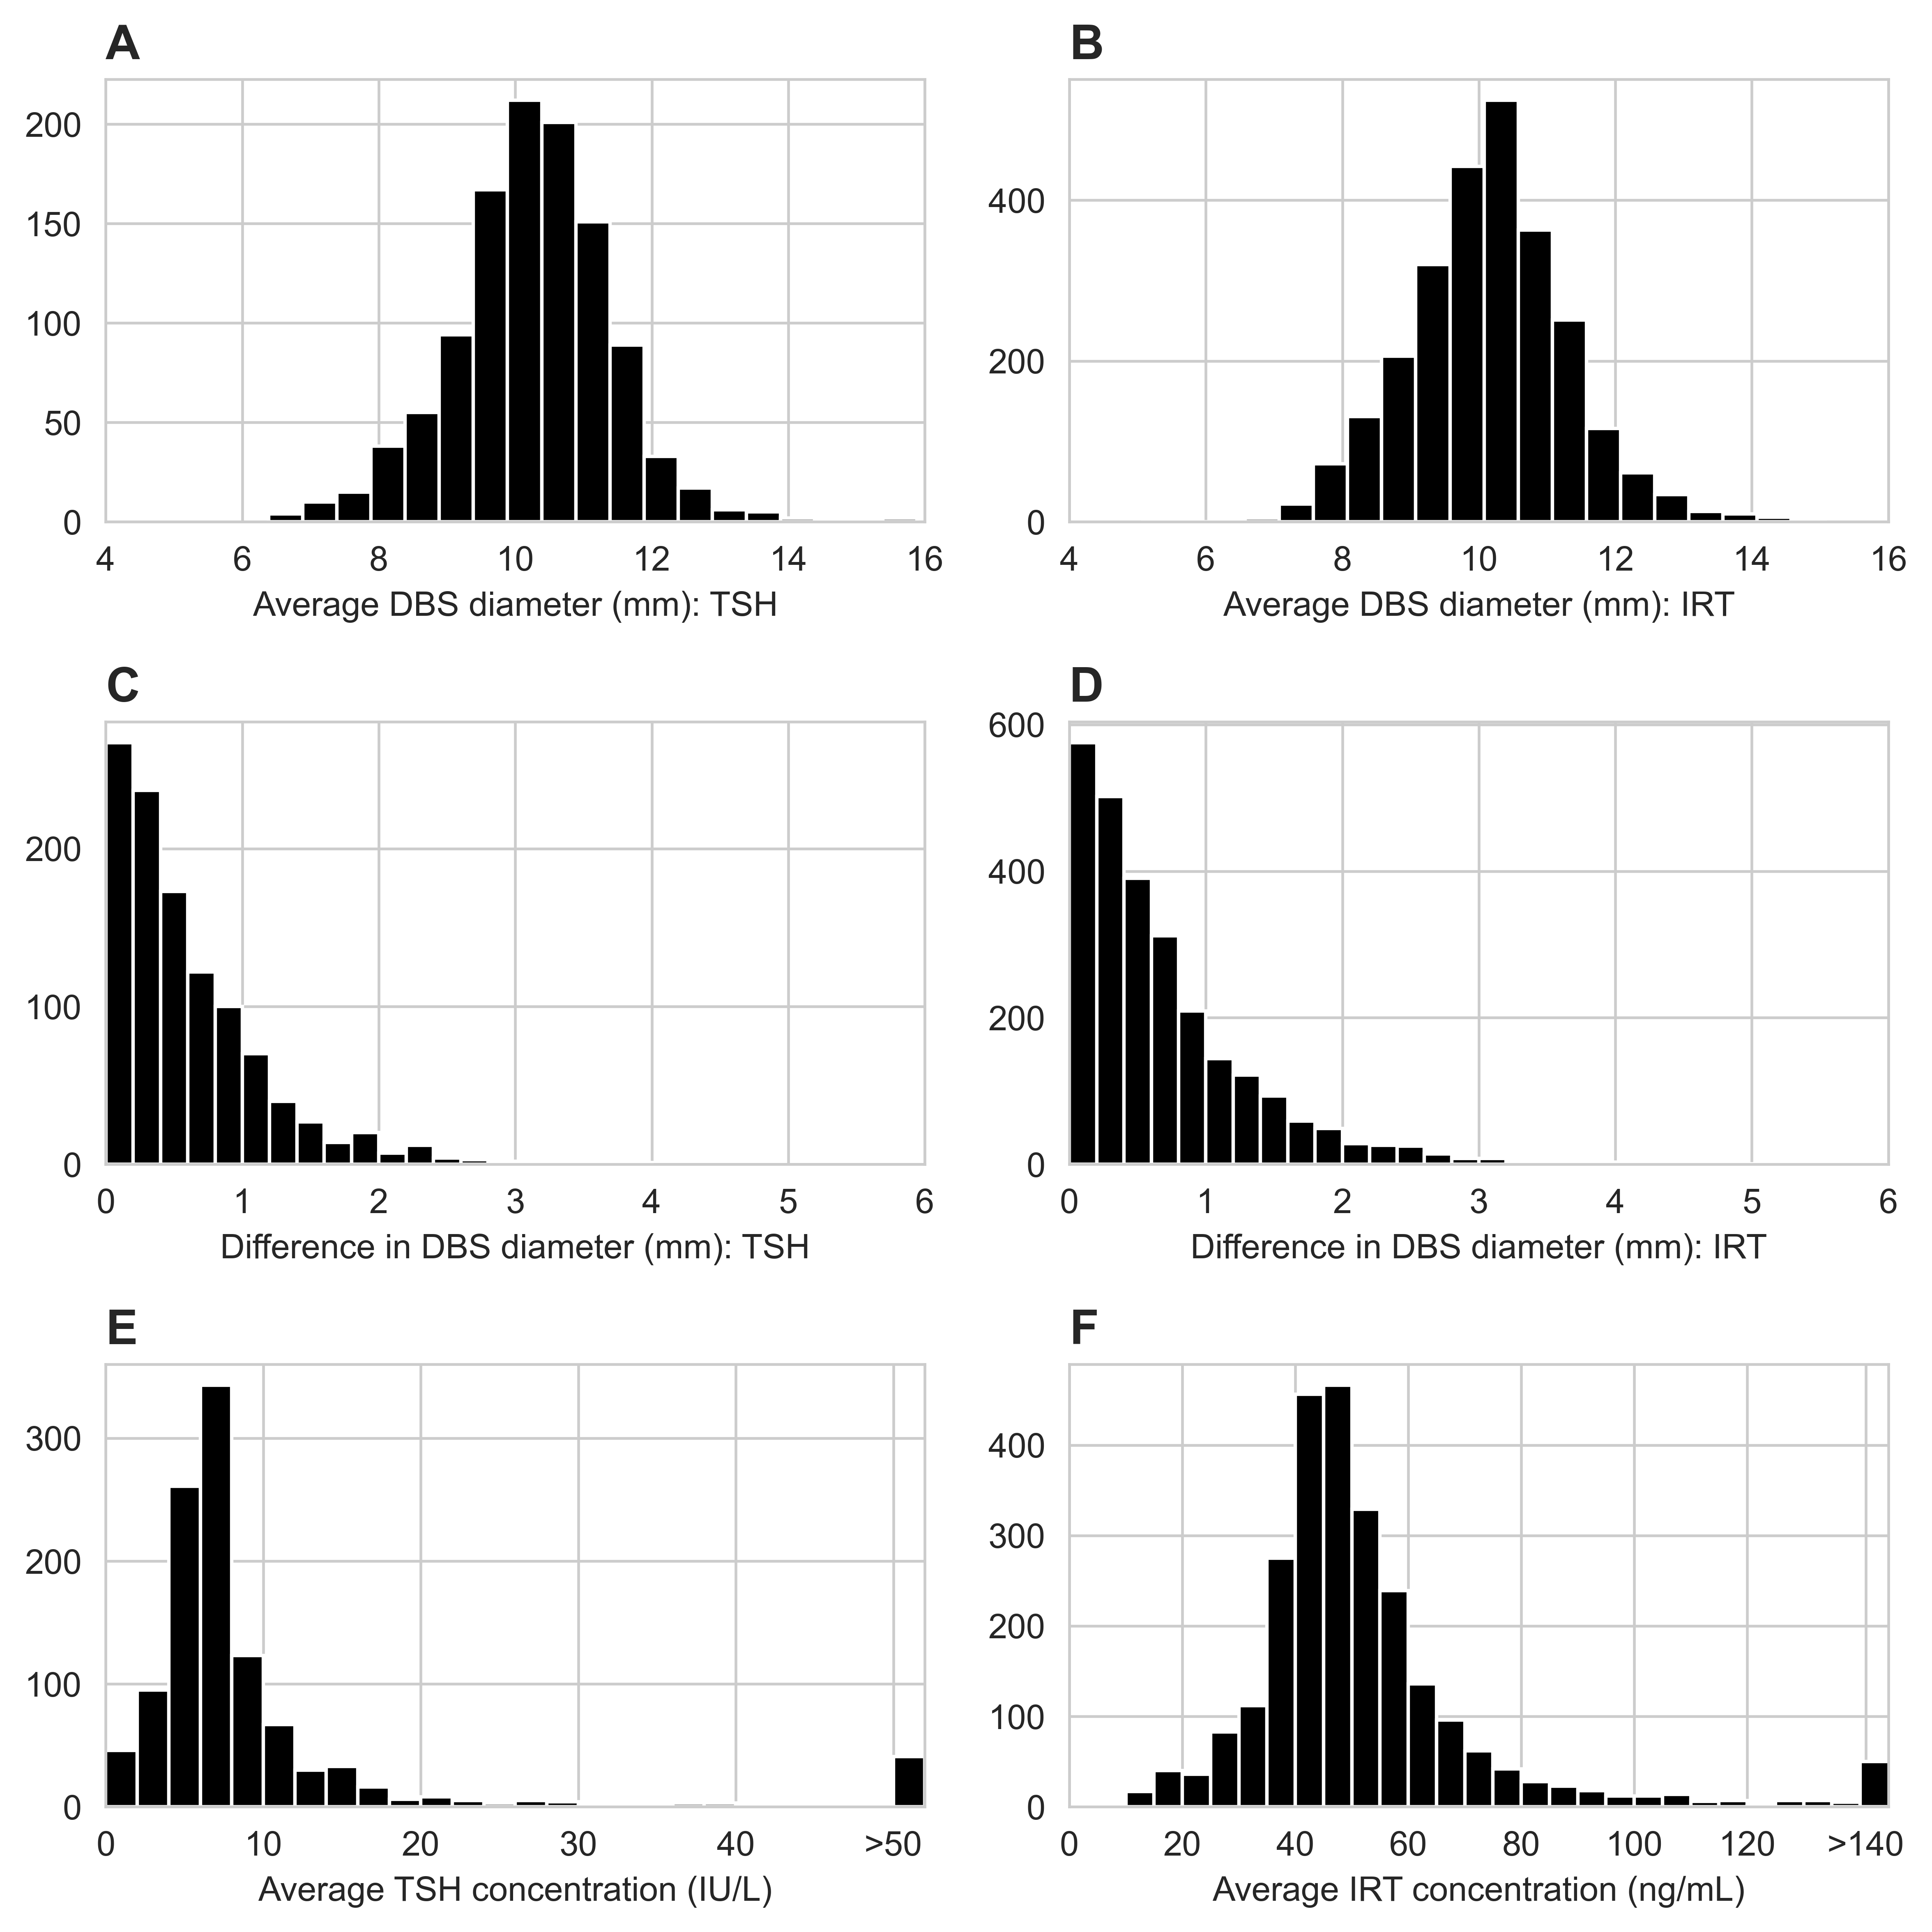

In [72]:
fig, axes = plt.subplots(3, 2, figsize=(8,8), dpi=600)

sns.set_theme(style="whitegrid")

# ----- Custom x-axis labels -----
xlabel_tsh_value = "Average TSH concentration (IU/L)"
xlabel_irt_value = "Average IRT concentration (ng/mL)"

# ----- PANEL A: TSH – avg_equiv_diam_mm -----
bin_width = 0.5
bins_a = np.arange(min(tsh["avg_equiv_diam_mm"].dropna()), max(tsh["avg_equiv_diam_mm"].dropna()) + bin_width, bin_width)


axes[0, 0].hist(tsh["avg_equiv_diam_mm"].dropna(), bins=bins_a, color='black')
axes[0, 0].set_xlabel("Average DBS diameter (mm): TSH")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("A", loc='left', fontsize=14, fontweight='bold')
axes[0, 0].set_xlim(4,16)
axes[0, 0].set_ylabel("")

# ----- PANEL B: IRT – avg_equiv_diam_mm -----

bin_width = 0.5
bins_b = np.arange(min(irt["avg_equiv_diam_mm"].dropna()), max(irt["avg_equiv_diam_mm"].dropna()) + bin_width, bin_width)

axes[0, 1].hist(irt["avg_equiv_diam_mm"].dropna(), bins=bins_b, color='black')
axes[0, 1].set_xlabel("Average DBS diameter (mm): IRT")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("B", loc='left', fontsize=14, fontweight='bold')
axes[0, 1].set_xlim(4,16)
axes[0, 1].set_ylabel("")


# ----- PANEL C: TSH – diff_equiv_diam_mm -----
bin_width = 0.2
bins_c = np.arange(min(tsh["diff_equiv_diam_mm"].dropna()), max(tsh["diff_equiv_diam_mm"].dropna()) + bin_width, bin_width)

axes[1, 0].hist(tsh["diff_equiv_diam_mm"].dropna(), bins=bins_c, color='black')
axes[1, 0].set_xlabel("Difference in DBS diameter (mm): TSH")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("C", loc='left', fontsize=14, fontweight='bold')
axes[1, 0].set_xlim(0,6)
axes[1, 0].set_ylabel("")

# ----- PANEL D: IRT – diff_equiv_diam_mm -----
bin_width = 0.2
bins_d = np.arange(min(irt["diff_equiv_diam_mm"].dropna()), max(irt["diff_equiv_diam_mm"].dropna()) + bin_width, bin_width)

axes[1, 1].hist(irt["diff_equiv_diam_mm"].dropna(), bins=bins_d, color='black')
axes[1, 1].set_xlabel("Difference in DBS diameter (mm): IRT")
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("D", loc='left', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim(0,6)
axes[1, 1].set_ylabel("")

## ----- PANEL E: TSH – concentration

# Bin width
bin_width = 2

# Regular bins from 0 to 50
bin_edges = np.arange(0, 52, bin_width)   # 0,2,4,...,50

overflow_bin = 51  # bucket all >50 here

# Cap values above 50
tsh['capped_value'] = np.where(
    tsh['avg_value'] > overflow_bin, overflow_bin, tsh['avg_value']
)

ax = axes[2,0]  # target subplot

# Plot histogram with custom bins
sns.histplot(
    tsh['capped_value'],
    bins=np.append(bin_edges, overflow_bin + 1),  # include overflow bin
    color='black',
    alpha=1,
    edgecolor='white',
    linewidth=1,
    ax=ax
)

# Desired ticks
ticks = [0, 10, 20, 30, 40, 50]   # 51 = overflow position
tick_labels = ["0", "10", "20", "30", "40", ">50"]

ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("")
ax.set_xlabel(xlabel_tsh_value)
ax.set_xlim(0, 52)
axes[2, 0].set_title("E", loc='left', fontsize=14, fontweight='bold')

## ----- PANEL F: IRT – concentration

# Bin width
bin_width = 5

# Regular bins from 0 to 140
bin_edges = np.arange(0, 142, bin_width)   # 0,2,4,...,50

overflow_bin = 145  # bucket all >50 here

# Cap values above 140
irt['capped_value'] = np.where(
    irt['avg_value'] > overflow_bin, overflow_bin, irt['avg_value']
)

ax = axes[2,1]  # target subplot

# Plot histogram with custom bins
sns.histplot(
    irt['capped_value'],
    bins=np.append(bin_edges, overflow_bin + 1),  # include overflow bin
    color='black',
    alpha=1,
    edgecolor='white',
    linewidth=1,
    ax=ax
)

# Desired ticks
ticks = [0, 20, 40, 60, 80, 100, 120, 141]   # 151 = overflow position
tick_labels = ["0", "20", "40", "60", "80", "100", "120", ">140"]

ax.set_xticks(ticks)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("")
ax.set_xlim(0, 145)
axes[2, 1].set_xlabel(xlabel_irt_value)
axes[2, 1].set_title("F", loc='left', fontsize=14, fontweight='bold')

plt.tight_layout()

Add categories for difference to help visualise differences

In [73]:
tsh['average_mm_diff_category'] = pd.cut(tsh['diff_equiv_diam_mm'],
                                               bins=[0,0.5,1,100],
                                              labels=["0-0.5","0.5-1.0",">1"])

irt['average_mm_diff_category'] = pd.cut(irt['diff_equiv_diam_mm'],
                                               bins=[0,0.5,1,100],
                                              labels=["0-0.5","0.5-1.0",">1"])

In [74]:
tsh['average_mm_diff_category'].value_counts()

0-0.5      595
0.5-1.0    303
>1         203
Name: average_mm_diff_category, dtype: int64

In [75]:
irt['average_mm_diff_category'].value_counts()

0-0.5      1285
0.5-1.0     702
>1          594
Name: average_mm_diff_category, dtype: int64

## OLS analysis (full dataset)

In [76]:
import statsmodels.api as sm

X = sm.add_constant(tsh['diff_equiv_diam_mm'])
y = tsh['pct_diff_value']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         pct_diff_value   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     26.12
Date:                Wed, 06 May 2026   Prob (F-statistic):           3.78e-07
Time:                        20:56:13   Log-Likelihood:                -4166.5
No. Observations:                1101   AIC:                             8337.
Df Residuals:                    1099   BIC:                             8347.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.4490      0

In [77]:
X = sm.add_constant(irt['diff_equiv_diam_mm'])
y = irt['pct_diff_value']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         pct_diff_value   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     29.88
Date:                Wed, 06 May 2026   Prob (F-statistic):           5.04e-08
Time:                        20:56:13   Log-Likelihood:                -11255.
No. Observations:                2581   AIC:                         2.251e+04
Df Residuals:                    2579   BIC:                         2.253e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.9111      0

## Define subgroups and sensitivity analyses

In [78]:
## TSH

# Paired on well positions
tsh_pp = tsh[tsh['merge_type'] == 'plate_positions']

# DBS diameter difference < 1.5 mm
tsh_dbsd1 = tsh[tsh['diff_equiv_diam_mm'] <= 1.5]

# TSH 6.0 – 10.0 mU/
tsh610 = tsh[(tsh['avg_value'] >= 6.0) & (tsh['avg_value'] < 10)]

# TSH ≥ 8.0 mU/L
tsh8 = tsh[tsh['avg_value'] >= 8.0]

# DBS diameter tertiles
tsh['dbs_tertile'], bins = pd.qcut(tsh['smallest_dbs'], q=3, labels=['low', 'mid', 'high'], retbins=True)

tsh_tertile1 = tsh[tsh['dbs_tertile'] == 'low']
tsh_tertile2 = tsh[tsh['dbs_tertile'] == 'mid']
tsh_tertile3 = tsh[tsh['dbs_tertile'] == 'high']


dfs_tsh={
    "All": tsh,
    "Paired on well positions":tsh_pp,
"DBS diameter difference < 1.5 mm":tsh_dbsd1,
"TSH 6.0 – 10.0 mU/L":tsh610,
"TSH ≥ 8.0 mU/L":tsh8,
f"Lower DBS diameter tertile (< {round(bins[1],1)} mm)":tsh_tertile1,
f"Central DBS diameter tertile ({round(bins[1],1)} - {round(bins[2],1)} mm)":tsh_tertile2,
f"Upper DBS diameter tertile (≥ {round(bins[2],1)} mm)":tsh_tertile3
}


## IRT
# Paired on well positions
irt_pp = irt[irt['merge_type'] == 'plate_positions']

# DBS diameter difference < 1.5 mm
irt_dbsd1 = irt[irt['diff_equiv_diam_mm'] <= 1.5]

# IRT 42.0 - 70.0 ng/mL
irt25 = irt[(irt['avg_value'] >= 42) & (irt['avg_value'] <= 70)]

# IRT ≥ 56 ng/mL
irt56 = irt[irt['avg_value']>=56]

## DBS diameter tertiles
irt['dbs_tertile'], bins = pd.qcut(irt['smallest_dbs'], q=3, labels=['low', 'mid', 'high'], retbins=True)

irt_tertile1 = irt[irt['dbs_tertile'] == 'low']
irt_tertile2 = irt[irt['dbs_tertile'] == 'mid']
irt_tertile3 = irt[irt['dbs_tertile'] == 'high']

dfs_irt={
    "All": irt,
    "Paired on well positions":irt_pp,
"DBS diameter difference < 1.5 mm":irt_dbsd1,
"IRT 42.0 – 70.0 ng/mL":irt25,
"IRT ≥ 56 ng/mL":irt56,
f"Lower DBS diameter tertile (< {round(bins[1],1)} mm)":irt_tertile1,
f"Central DBS diameter tertile ({round(bins[1],1)} - {round(bins[2],1)} mm)":irt_tertile2,
f"Upper DBS diameter tertile (≥ {round(bins[2],1)} mm)":irt_tertile3
}


In [79]:
def run_ols_across_dataframes(df_dict, x_var='diff_equiv_diam_mm', y_var='pct_diff_value'):
    """
    Function to produce sensitivity/subgroup analysis table
    
    df_dict: dict of {name: dataframe}
    x_var: predictor variable
    y_var: outcome variable
    """

    results = []

    for name, df in df_dict.items():
        d = df[[x_var, y_var]].dropna()
        n_samples = len(d)

        X = sm.add_constant(d[x_var])
        y = d[y_var]

        model = sm.OLS(y, X).fit()

        coef = model.params[x_var]
        ci_low, ci_high = model.conf_int().loc[x_var]
        p_value = model.pvalues[x_var]
        r2 = model.rsquared

        # Format coefficient + CI (2 decimal places)
        coef_with_ci = f"{coef:.2f} ({ci_low:.2f} - {ci_high:.2f})"

        # Format p-value
        if p_value < 0.001:
            p_val_formatted = "< 0.001"
        else:
            p_val_formatted = f"{p_value:.3f}"

        results.append({
            "Subgroup": name,
            "n": n_samples,
            "% change in analyte concentration per mm change in DBS diameter difference (95% confidence interval)": coef_with_ci,
            "R²": round(r2, 3),
            "p-value": p_val_formatted
        })

    return pd.DataFrame(results)


In [80]:
tsh_ols_results = run_ols_across_dataframes(dfs_tsh)
tsh_ols_results.to_csv('tsh_duplicates_ols.csv',index=False)
tsh_ols_results

,Subgroup,n,% change in analyte concentration per mm change in DBS diameter difference (95% confidence interval),R²,p-value
0,All,1101,3.03 (1.87 - 4.19),0.023,< 0.001
1,Paired on well positions,682,2.98 (1.49 - 4.46),0.022,< 0.001
2,DBS diameter difference < 1.5 mm,1021,3.71 (1.94 - 5.48),0.016,< 0.001
3,TSH 6.0 – 10.0 mU/L,466,2.75 (1.07 - 4.43),0.022,0.001
4,TSH ≥ 8.0 mU/L,356,4.12 (1.90 - 6.34),0.036,< 0.001
5,Lower DBS diameter tertile (< 9.5 mm),367,4.35 (2.58 - 6.12),0.060,< 0.001
6,Central DBS diameter tertile (9.5 - 10.4 mm),367,2.35 (0.03 - 4.67),0.011,0.047
7,Upper DBS diameter tertile (≥ 10.4 mm),367,2.56 (0.34 - 4.78),0.014,0.024


In [81]:
irt_ols_results = run_ols_across_dataframes(dfs_irt)
irt_ols_results.to_csv('irt_duplicates_ols.csv',index=False)
irt_ols_results

,Subgroup,n,% change in analyte concentration per mm change in DBS diameter difference (95% confidence interval),R²,p-value
0,All,2581,3.05 (1.96 - 4.15),0.011,< 0.001
1,Paired on well positions,1187,3.18 (1.64 - 4.72),0.014,< 0.001
2,DBS diameter difference < 1.5 mm,2302,5.45 (3.45 - 7.44),0.012,< 0.001
3,IRT 42.0 – 70.0 ng/mL,1556,4.04 (2.82 - 5.25),0.027,< 0.001
4,IRT ≥ 56 ng/mL,703,2.47 (-0.07 - 5.02),0.005,0.057
5,Lower DBS diameter tertile (< 9.4 mm),861,2.04 (0.11 - 3.97),0.005,0.038
6,Central DBS diameter tertile (9.4 - 10.3 mm),860,5.12 (3.08 - 7.15),0.027,< 0.001
7,Upper DBS diameter tertile (≥ 10.3 mm),860,3.90 (2.03 - 5.78),0.019,< 0.001


## Figure 

In [82]:
def plot_mean_ci_figure(df, analyte, ax=None, panel_label=None):

    # --- Compute mean and 95% CI per category ---
    summary = (
        df.groupby('average_mm_diff_category', observed=True)['pct_diff_value']
          .agg(['mean', 'count', 'std'])
          .assign(
              sem=lambda x: x['std'] / np.sqrt(x['count']),
              ci95=lambda x: 1.96 * x['std'] / np.sqrt(x['count']),
              lower=lambda x: x['mean'] - 1.96 * x['std'] / np.sqrt(x['count']),
              upper=lambda x: x['mean'] + 1.96 * x['std'] / np.sqrt(x['count'])
          )
          .reset_index()
          .dropna(subset=['mean'])
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6), dpi=600)

    # Plot mean points
    sns.pointplot(
        data=summary,
        x='average_mm_diff_category',
        y='mean',
        color='black',
        join=False,
        errorbar=None,
        ax=ax
    )

    # Add 95% CI error bars
    ax.errorbar(
        x=np.arange(len(summary)),
        y=summary['mean'],
        yerr=summary['ci95'],
        fmt='none',
        ecolor='black',
        capsize=4,
        alpha=1
    )

    # Labels
    ax.set_xlabel("")
    #ax.set_xlabel('Difference in DBS diameter (mm)')
    ax.set_ylabel(f"Mean {analyte} % difference")
    
    if panel_label is not None:
        ax.text(
            0.05, 0.95, panel_label,
            transform=ax.transAxes,
            fontsize=14,
            va='top',
            ha='left',
            bbox=dict(
            facecolor='white',
            edgecolor='black',
            boxstyle='round,pad=0.5'
        )
        )
    
    return ax

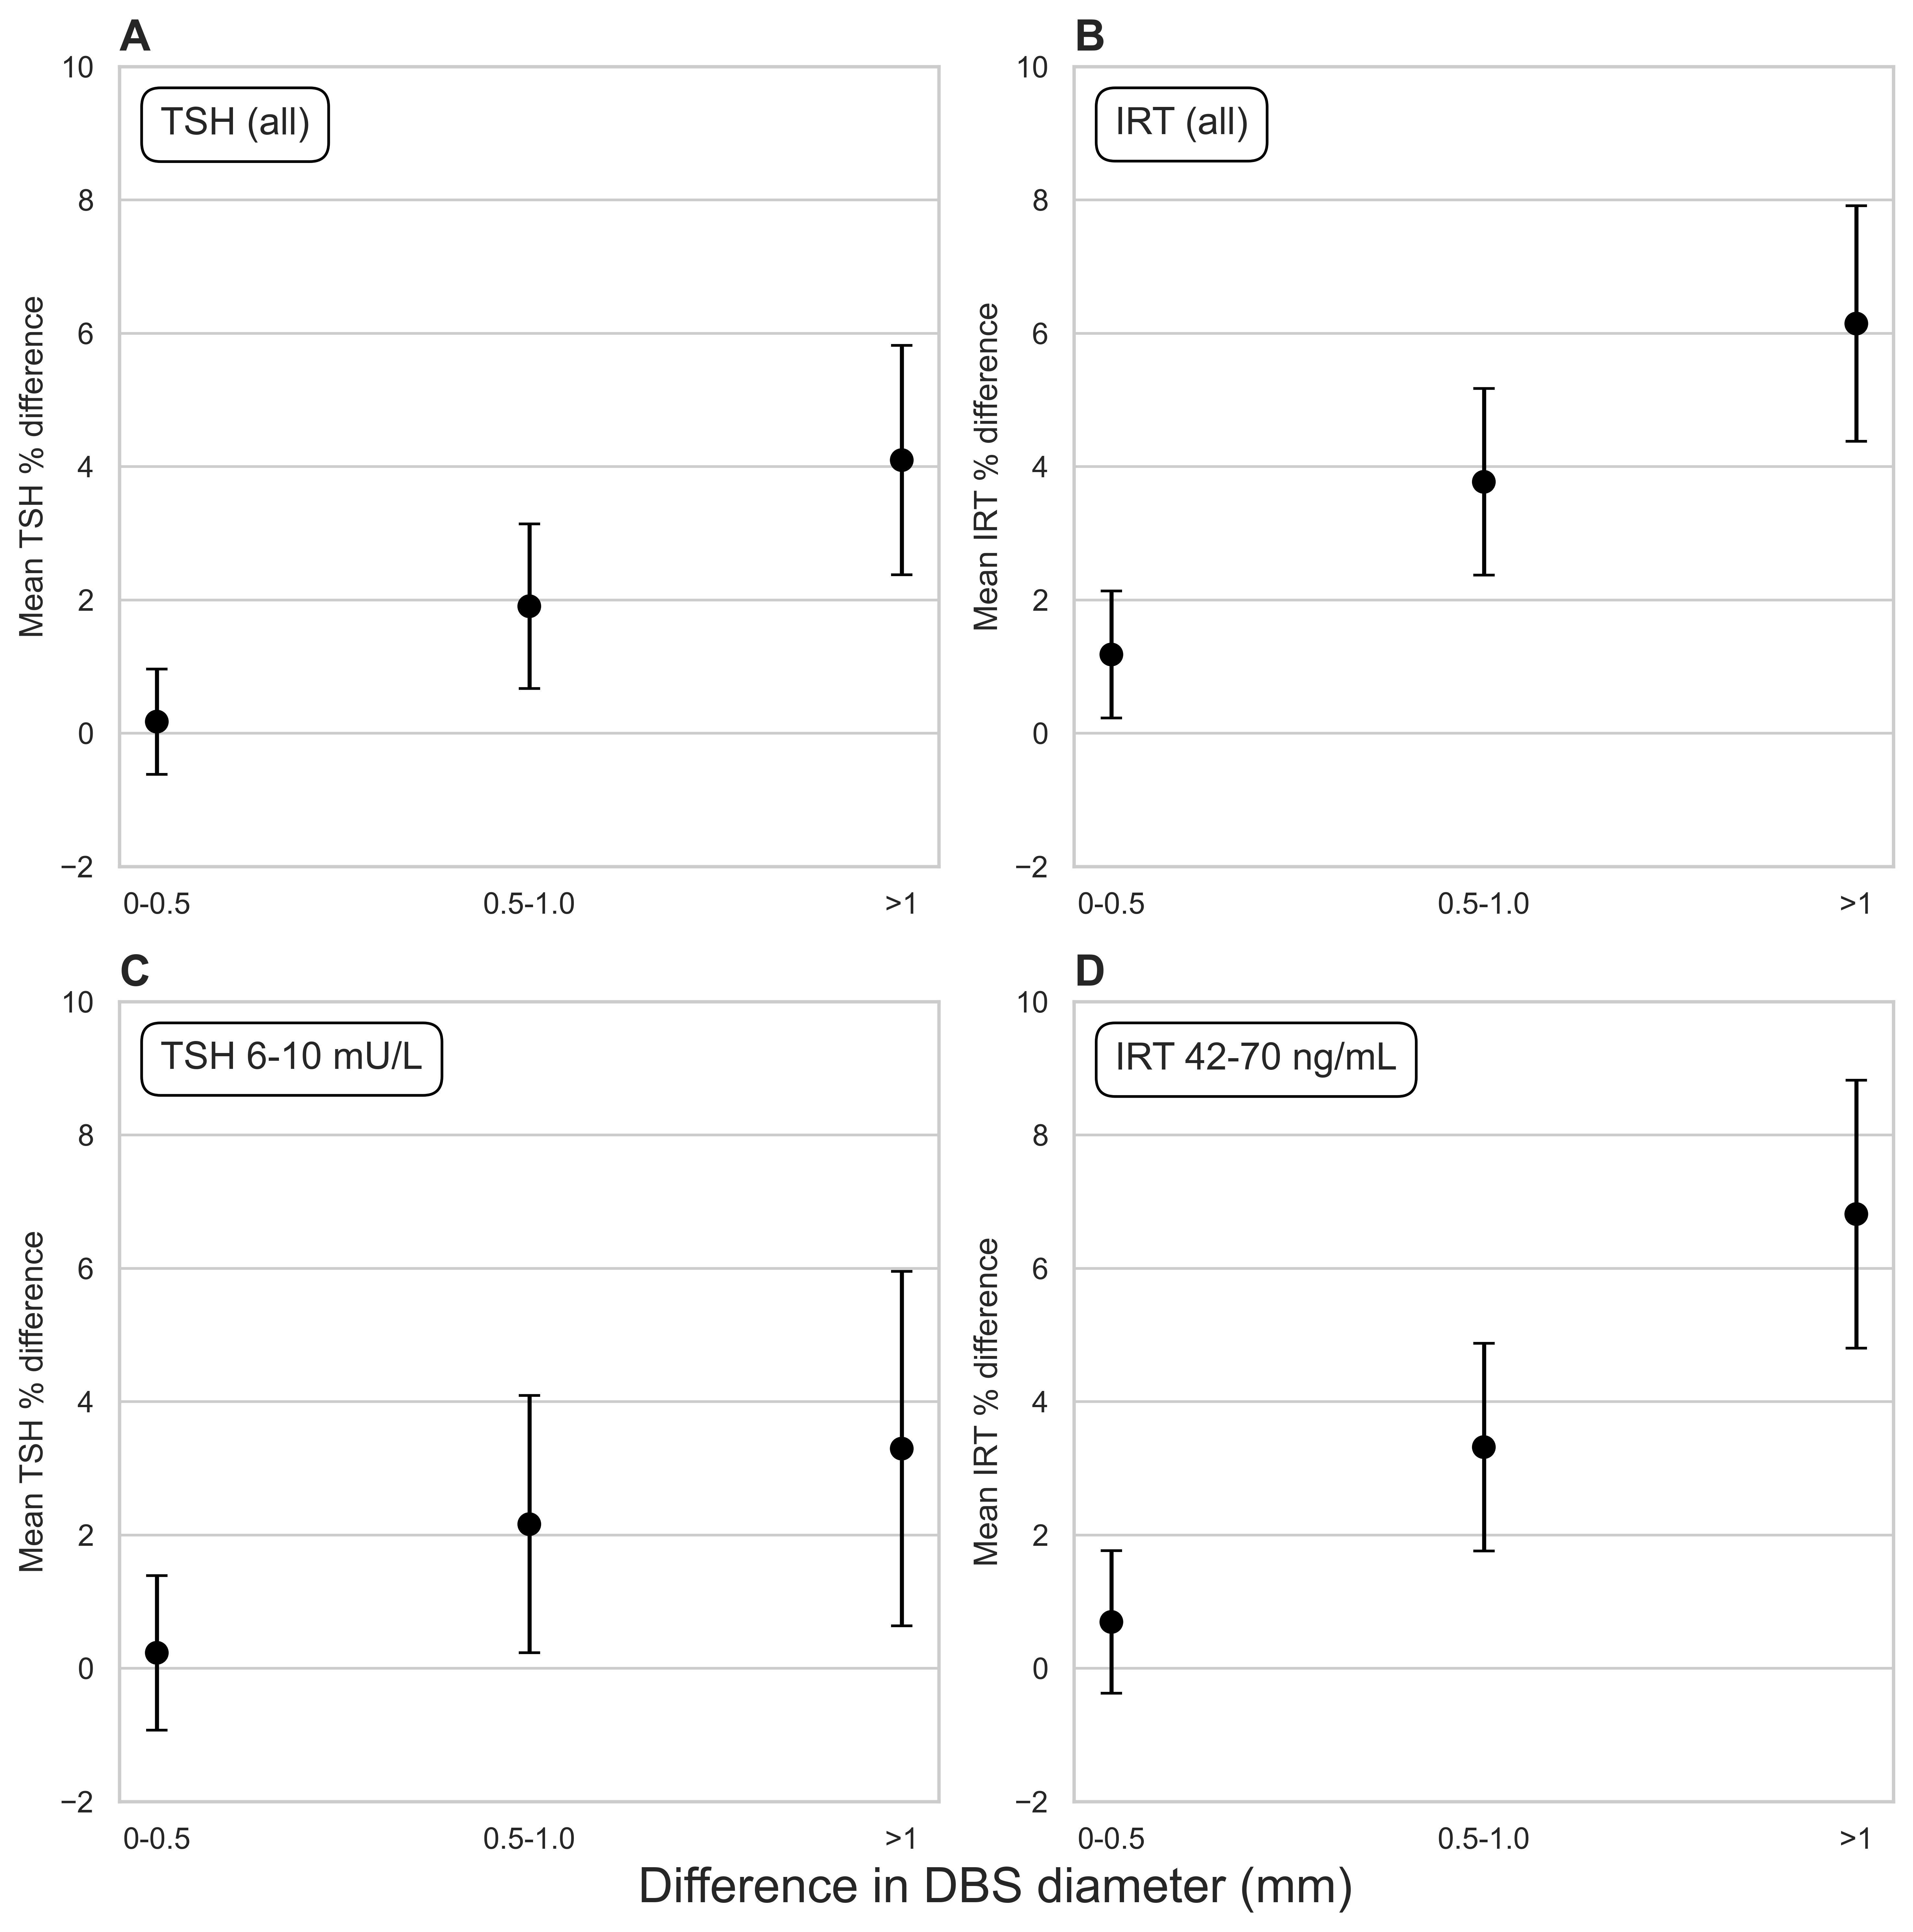

In [83]:
dfs = [tsh, irt, tsh610, irt25]
analytes = ['TSH', 'IRT', 'TSH', 'IRT']
figure_labels = ["TSH (all)", "IRT (all)", "TSH 6-10 mU/L", "IRT 42-70 ng/mL"]
panel_labels = ["A","B","C","D"]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=600)

for ax, df, analyte, label, figure_label in zip(axes.flat, dfs, analytes, panel_labels, figure_labels):
    plot_mean_ci_figure(df, analyte, ax=ax, panel_label=figure_label)
    ax.set_title(label, loc='left', fontsize=16, fontweight='bold')

for ax in axes.flat:
    ax.set_ylim(-2, 10)
    
# Shared x label (bottom centre)
fig.text(0.52, 0.02, "Difference in DBS diameter (mm)",
         ha="center", va="center", fontsize=18)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig('Figure1.jpg')

plt.show()

Get counts for figure legend

In [84]:
def format_category_legend(series):
    
    counts = series.value_counts()
    total_n = counts.sum()
    parts = []
    
    for cat, n in counts.items():
        if cat == ">1":
            label = ">1.0 mm"
        else:
            label = f"{cat} mm"
        parts.append(f"{label}: n={n}")
    
    return f"n={total_n}, Numbers per category: " + "; ".join(parts)


In [85]:
for df in dfs:
    print(format_category_legend(df['average_mm_diff_category']))

n=1101, Numbers per category: 0-0.5 mm: n=595; 0.5-1.0 mm: n=303; >1.0 mm: n=203
n=2581, Numbers per category: 0-0.5 mm: n=1285; 0.5-1.0 mm: n=702; >1.0 mm: n=594
n=466, Numbers per category: 0-0.5 mm: n=258; 0.5-1.0 mm: n=121; >1.0 mm: n=87
n=1556, Numbers per category: 0-0.5 mm: n=785; 0.5-1.0 mm: n=418; >1.0 mm: n=353
